
import all libraries needed



In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

to upload file

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving house_price.csv to house_price.csv


to extract the uploades file

In [ ]:
df=pd.read_csv('house_price.csv')

to show the data

In [ ]:
print(df.head())

   Area_sqft  Bedrooms  Bathrooms  Age_years  Distance_to_CityCenter_m  \
0       1200         2          1          5                      5000   
1       1500         3          2          3                      3000   
2        900         2          1         10                      8000   
3       2000         4          3          2                      1500   
4       1750         3          2          4                      2500   

        Location  Price_INR  
0      Hyderabad    4500000  
1      Hyderabad    6200000  
2       Warangal    2800000  
3     Vijayawada    8500000  
4  Visakhapatnam    7100000  


to understand the data

In [ ]:
print(df.shape)
print(df.columns)
print(df.info())
print(df.describe())

(20, 7)
Index(['Area_sqft', 'Bedrooms', 'Bathrooms', 'Age_years',
       'Distance_to_CityCenter_m', 'Location', 'Price_INR'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 7 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Area_sqft                 20 non-null     int64 
 1   Bedrooms                  20 non-null     int64 
 2   Bathrooms                 20 non-null     int64 
 3   Age_years                 20 non-null     int64 
 4   Distance_to_CityCenter_m  20 non-null     int64 
 5   Location                  20 non-null     object
 6   Price_INR                 20 non-null     int64 
dtypes: int64(6), object(1)
memory usage: 1.2+ KB
None
         Area_sqft   Bedrooms  Bathrooms  Age_years  Distance_to_CityCenter_m  \
count    20.000000  20.000000  20.000000  20.000000                 20.000000   
mean   1570.000000   2.950000   2.100000   5.7

check the missing values

In [ ]:
print(df.isnull().sum())

Area_sqft                   0
Bedrooms                    0
Bathrooms                   0
Age_years                   0
Distance_to_CityCenter_m    0
Location                    0
Price_INR                   0
dtype: int64


handling the missing values

In [ ]:
df.fillna(df.mean(numeric_only=True), inplace=True)

check duplicate rows

In [ ]:
print(df.duplicated().sum())

0


remove duplicates

In [ ]:
df.drop_duplicates(inplace=True)

encode categorical columns

In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df["Location"] = le.fit_transform(df["Location"])

explore the data

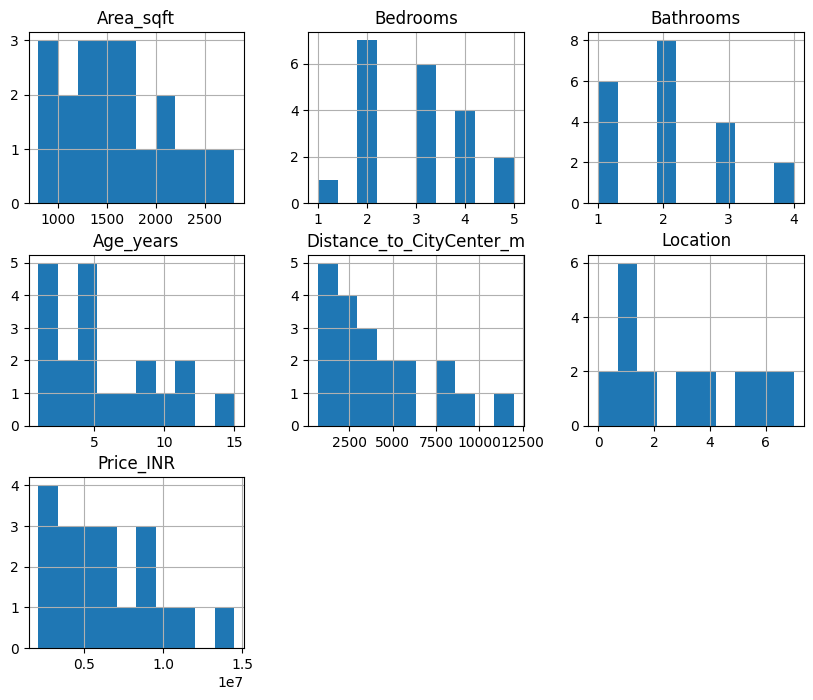

In [ ]:
df.hist(figsize=(10, 8))
plt.show()

correlation matrix

In [ ]:
print(df.corr(numeric_only=True))

                          Area_sqft  Bedrooms  Bathrooms  Age_years  \
Area_sqft                  1.000000  0.965169   0.946444  -0.881094   
Bedrooms                   0.965169  1.000000   0.945000  -0.886116   
Bathrooms                  0.946444  0.945000   1.000000  -0.831035   
Age_years                 -0.881094 -0.886116  -0.831035   1.000000   
Distance_to_CityCenter_m  -0.866369 -0.865453  -0.814427   0.976552   
Location                  -0.139254 -0.122813  -0.069726   0.204578   
Price_INR                  0.994737  0.958317   0.945597  -0.868537   

                          Distance_to_CityCenter_m  Location  Price_INR  
Area_sqft                                -0.866369 -0.139254   0.994737  
Bedrooms                                 -0.865453 -0.122813   0.958317  
Bathrooms                                -0.814427 -0.069726   0.945597  
Age_years                                 0.976552  0.204578  -0.868537  
Distance_to_CityCenter_m                  1.000000  0.218112 

select features and targets

In [ ]:
print(df.columns)

Index(['Area_sqft', 'Bedrooms', 'Bathrooms', 'Age_years',
       'Distance_to_CityCenter_m', 'Location', 'Price_INR'],
      dtype='object')


In [ ]:
# Features (X)
X = df[["Area_sqft", "Bedrooms", "Bathrooms"]]

# Target (y)
y = df["Price_INR"]

split the train and testing data

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

train the model

In [ ]:
model = LinearRegression()

model.fit(X_train, y_train)

LinearRegression()

make the prediction

In [ ]:
predictions = model.predict(X_test)

print(predictions)

[4038116.65303897 2561283.72853637 7073800.76315072 5892334.42354865]


predict the price of new house

In [ ]:
new_house = [[1500, 3, 2]]

price = model.predict(new_house)

print("Predicted Price:", price)

Predicted Price: [5892334.42354865]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


import model

In [ ]:
import joblib

joblib.dump(model, "house_price_model.pkl")

['house_price_model.pkl']

In [ ]:
load it l